In [2]:
import pandas as pd

# --- File paths (update if needed) ---
recycled_corrected = "data/AllData_PreEDM_Recycled_RowColIDs_correcteddates.csv"
recycled_raw       = "data/AllData_PreEDM_Recycled_RowColIDs.csv"
virgin_corrected   = "data/AllData_PreEDM_Virgin_RowColIDs_correcteddates.csv"
virgin_raw         = "data/AllData_PreEDM_Virgin_RowColIDs.csv"

# --- Load datasets ---
rec_corr = pd.read_csv(recycled_corrected)
rec_raw  = pd.read_csv(recycled_raw)
vir_corr = pd.read_csv(virgin_corrected)
vir_raw  = pd.read_csv(virgin_raw)

print(len(rec_corr), len(rec_raw), len(vir_corr), len(vir_raw))


784 784 776 776


In [3]:
df_recycled = rec_corr.copy()
df_virgin = vir_corr.copy()


In [4]:
df_recycled["PowderPhase"] = "Recycled"
df_virgin["PowderPhase"] = "Virgin"


In [5]:
df = pd.concat([df_recycled, df_virgin], ignore_index=True)
print(df.shape)


(1560, 18)


In [6]:
df["Nonconformity"] = df["Nonconformity"].astype(int)  # or bool if needed


In [7]:
layout_map = {
    "6X6": "6x6",
    "6X6 + TA": "6x6+TA",
    "11X11 + TA": "11x11+TA"
}

df["Layout"] = df["Layout"].replace(layout_map)


In [8]:
df["Layout"].value_counts()


Layout
11X11TA    1344
6x6         108
6X6TA       108
Name: count, dtype: int64

In [9]:
df["BuildDate"] = pd.to_datetime(df["BuildDate"], errors="coerce")


/var/folders/n5/50bl5l7j7nx717mns6lylg800000gn/T/ipykernel_49201/4202476020.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["BuildDate"] = pd.to_datetime(df["BuildDate"], errors="coerce")


In [10]:
print(df["PowderPhase"].value_counts())
print(df["Layout"].value_counts())
print(df["Nonconformity"].value_counts(normalize=True))
df.head()


PowderPhase
Recycled    784
Virgin      776
Name: count, dtype: int64
Layout
11X11TA    1344
6x6         108
6X6TA       108
Name: count, dtype: int64
Nonconformity
0    0.990385
1    0.009615
Name: proportion, dtype: float64


,Row,B3_DATUM_B_LOC,B3_REF_OD,C1_LOC_INSIDE_PLN,C4_LOC_TOP_PLN,B3_THICK1_WALL,B3_THICK2_WALL,B3_THICK3_WALL,B3_THICK4_WALL,Layout,BuildDate,Powder,MeasureSeq,Nonconformity,RowID,ColID,PlateID,PowderPhase
0,La1,0.4171,0.4476,0.0539,0.2659,0.0158,0.0160,0.0149,0.0164,11X11TA,2019-08-29,Recycled,PreEDM,0,1,1,L,Recycled
1,La2,0.4164,0.4478,0.0534,0.2662,0.0168,0.0167,0.0152,0.0141,11X11TA,2019-08-29,Recycled,PreEDM,0,1,2,L,Recycled
2,La3,0.4173,0.4479,0.0541,0.2668,0.0151,0.0163,0.0155,0.0151,11X11TA,2019-08-29,Recycled,PreEDM,0,1,3,L,Recycled
3,La4,0.4172,0.4485,0.0531,0.2663,0.0155,0.0157,0.0183,0.0147,11X11TA,2019-08-29,Recycled,PreEDM,0,1,4,L,Recycled
4,La5,0.4175,0.4487,0.0541,0.2663,0.0153,0.0153,0.0156,0.0153,11X11TA,2019-08-29,Recycled,PreEDM,0,1,5,L,Recycled


In [11]:
df.shape, df["PowderPhase"].value_counts(), df["Layout"].value_counts()


((1560, 18),
 PowderPhase
 Recycled    784
 Virgin      776
 Name: count, dtype: int64,
 Layout
 11X11TA    1344
 6x6         108
 6X6TA       108
 Name: count, dtype: int64)

In [13]:
df.columns.tolist()


['Row',
 'B3_DATUM_B_LOC',
 'B3_REF_OD',
 'C1_LOC_INSIDE_PLN',
 'C4_LOC_TOP_PLN',
 'B3_THICK1_WALL',
 'B3_THICK2_WALL',
 'B3_THICK3_WALL',
 'B3_THICK4_WALL',
 'Layout',
 'BuildDate',
 'Powder',
 'MeasureSeq',
 'Nonconformity',
 'RowID',
 'ColID',
 'PlateID',
 'PowderPhase']

In [14]:
df["Row"] = pd.to_numeric(df["RowID"], errors="coerce")
df["Col"] = pd.to_numeric(df["ColID"], errors="coerce")


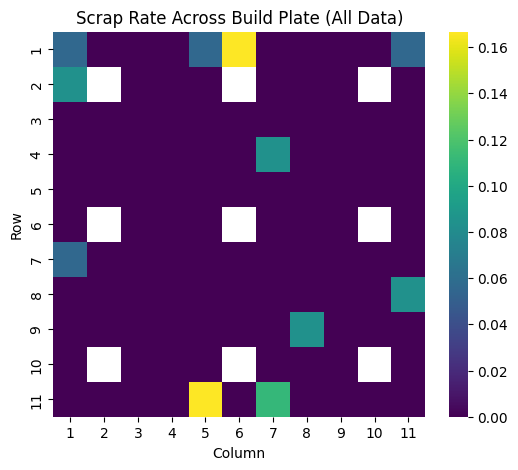

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ensure row/col numeric
df["Row"] = pd.to_numeric(df["Row"], errors="coerce")
df["Col"] = pd.to_numeric(df["Col"], errors="coerce")

# compute scrap rate by position
grid = df.groupby(["Row","Col"])["Nonconformity"].mean().reset_index()

pivot = grid.pivot(index="Row", columns="Col", values="Nonconformity")

plt.figure(figsize=(6,5))
sns.heatmap(pivot, cmap="viridis", annot=False)
plt.title("Scrap Rate Across Build Plate (All Data)")
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()


Scrap risk is spatially concentrated at the outer build-plate edges and specific thermal accumulation zones.

Parts located near corners or edge rows/columns exhibit higher failure probability, while central positions remain stable.

This strongly suggests that thermal gradients and scan-path energy distribution drive dimensional distortion leading to nonconformity.